# Проект

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import shap
import sklearn

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

from sklearn.experimental import enable_iterative_imputer
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
from sklearn.impute import IterativeImputer
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler

from darts import TimeSeries
from darts.metrics import wmape

import warnings
warnings.filterwarnings('ignore')

pd.options.display.max_columns = None
sklearn.set_config(transform_output='pandas')
pd.set_option('display.max_columns', None)

c:\Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Достаем данные

In [2]:
path = kagglehub.dataset_download("shahpranshu27/rossman-store-sales")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\arutg\.cache\kagglehub\datasets\shahpranshu27\rossman-store-sales\versions\1


In [3]:
train = pd.read_csv(path + '/rossmann-store-sales/train.csv', low_memory=False, parse_dates=['Date'])
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
store = pd.read_csv(path + '/rossmann-store-sales/store.csv', low_memory=False)
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
store[['Promo2SinceWeek', 'Promo2SinceYear']] = store[['Promo2SinceWeek', 'Promo2SinceYear']].fillna(0)

In [6]:
cat_features = ['Store', 'StoreType', 'Assortment', 'StateHoliday', 'DayOfWeek']

## Объединим train и store в один датафрейм для обучения

In [7]:
df = train.merge(store, on='Store', how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,NaN


In [8]:
df = df.sort_values(by='Date').reset_index(drop=True)
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"
1,379,2,2013-01-01,0,0,0,0,a,1,d,a,6630.0,NaN,NaN,0,0.0,0.0,NaN
2,378,2,2013-01-01,0,0,0,0,a,1,a,c,2140.0,8.0,2012.0,0,0.0,0.0,NaN
3,377,2,2013-01-01,0,0,0,0,a,1,a,c,100.0,6.0,2010.0,1,18.0,2010.0,"Feb,May,Aug,Nov"
4,376,2,2013-01-01,0,0,0,0,a,1,a,a,160.0,8.0,2012.0,0,0.0,0.0,NaN


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

# EDA

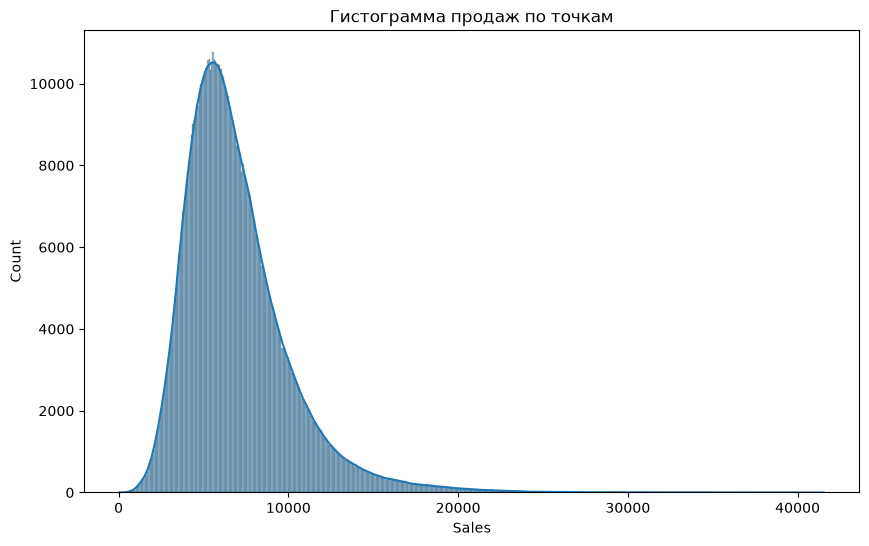

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df[df['Sales'] > 0], x='Sales', kde=True, ax=ax)
ax.set_title('Гистограмма продаж по точкам')
plt.show()

В основном за день один магазин зарабатывает около 8к евро

In [11]:
print(f"Коэф. ассиметрии = {df[df['Sales'] > 0]['Sales'].skew().item():.3f}. Пик смещен влево")
print(f"Коэф. эксцесса = {df[df['Sales'] > 0]['Sales'].kurt().item():.3f}. Пик острый")

Коэф. ассиметрии = 1.595. Пик смещен влево
Коэф. эксцесса = 4.854. Пик острый


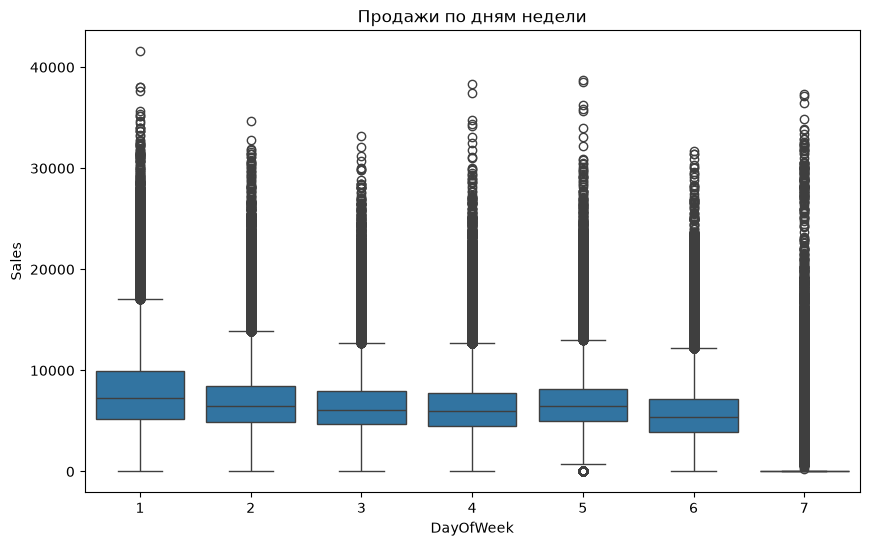

In [12]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='DayOfWeek', y='Sales', ax=ax)
ax.set_title('Продажи по дням недели')
plt.show()

Основная доля продаж приходится на воскресенье и понедельник

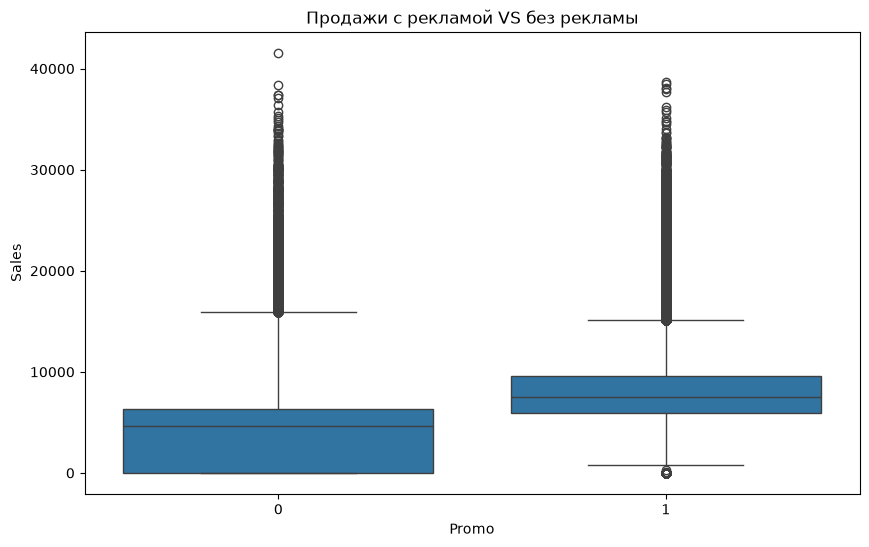

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='Promo', y='Sales', ax=ax)
ax.set_title('Продажи с рекламой VS без рекламы')
plt.show()

Реклама позитивно влияет на продажи

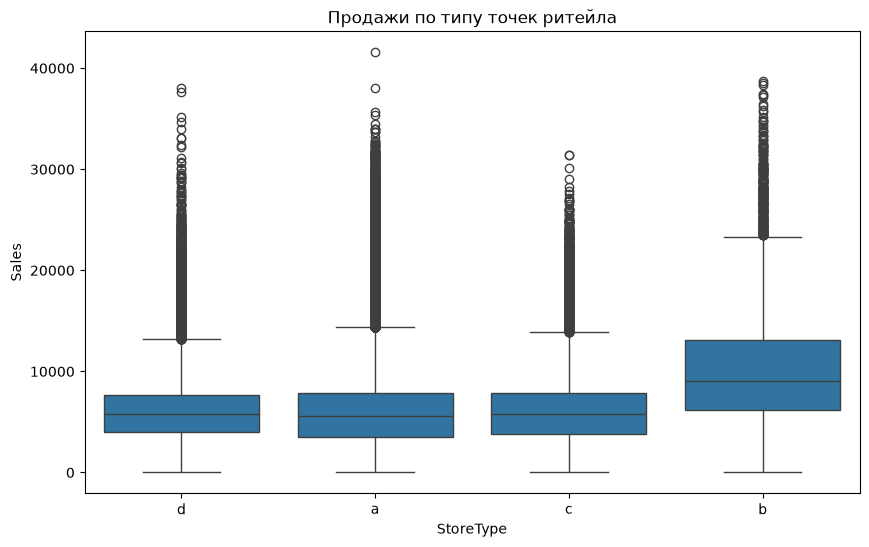

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='StoreType', y='Sales', ax=ax)
ax.set_title('Продажи по типу точек ритейла')
plt.show()

Точки ритейла типа b лучше всего продаются

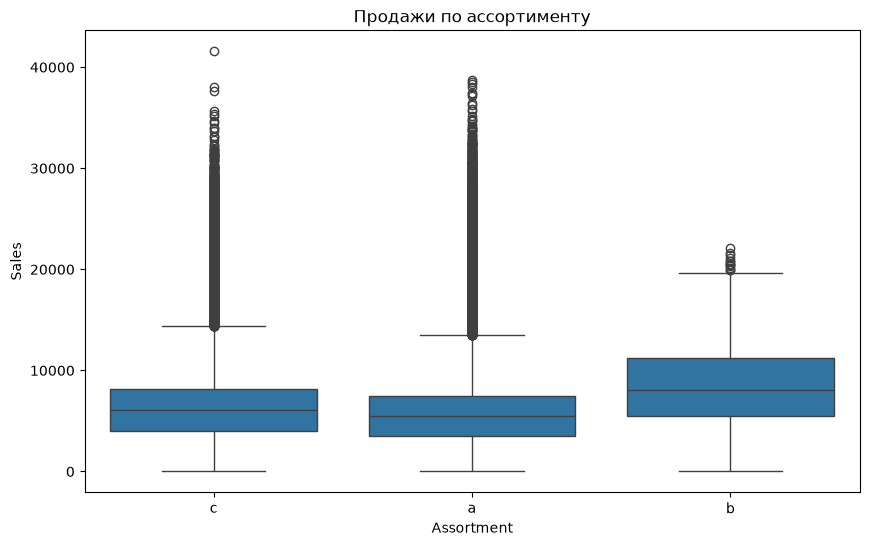

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(df, x='Assortment', y='Sales', ax=ax)
ax.set_title('Продажи по ассортименту')
plt.show()

Ассортимент b лучше всего продается

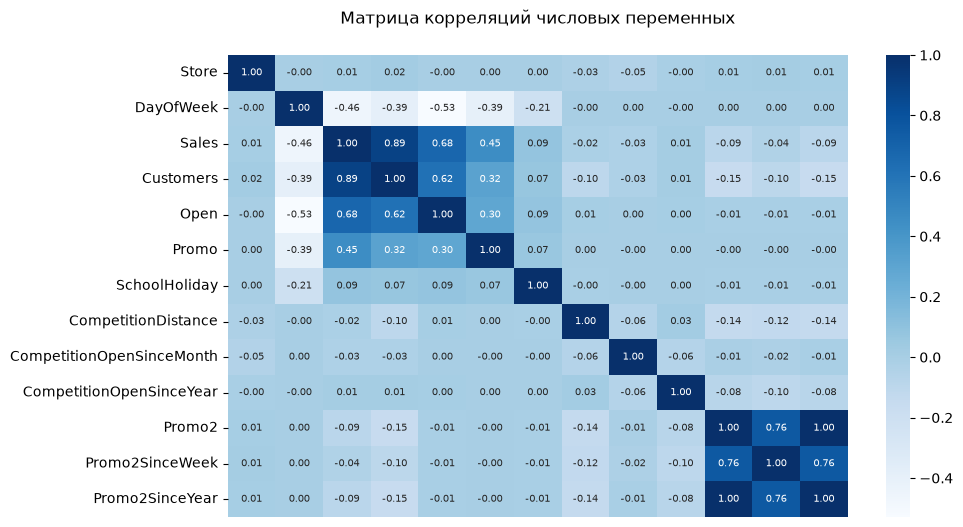

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap='Blues',
    annot=True,
    fmt='.2f',
    annot_kws={"size": 7},
    xticklabels=False,
    ax=ax
)
ax.set_title('Матрица корреляций числовых переменных', y=1.05)
plt.show()

Видно, что Customers и Promo сильно коррелируют с таргетом

# Feature Engineering

## Фичи по дате

In [17]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['DayOfMonth'] = df['Date'].dt.day
df['DayOfYear'] = df['Date'].dt.day_of_year

## Фичи по конкурентам
Сколько месяцев на текущий момент функционирует конкурент. От текущей даты вычитаем дату открытия и переводим в месяцы

In [18]:
competitors_dates = {
    'year': df['CompetitionOpenSinceYear'],
    'month': df['CompetitionOpenSinceMonth'],
    'day': 1
}

df_dates = pd.to_datetime(competitors_dates)
diff = (df['Date'].dt.to_period('M') - df_dates.dt.to_period('M')).apply(lambda x: x.n if pd.notna(x) else np.nan)

df['CompetitionMonths'] = diff
df = df.drop(columns=['CompetitionOpenSinceYear', 'CompetitionOpenSinceMonth'])

## Бинарная фича из PromoIntertest

In [19]:
months_mapping = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10,
'Nov': 11, 'Dec': 12}

def func_filter(row):
    if isinstance(row, list):
        return [months_mapping[x] for x in row]
    else:
        return [0]

In [20]:
df['PromoInterval'] = df['PromoInterval'].str.split(',').apply(func_filter)

In [21]:
df['Promo2Exists'] = df.apply(lambda row: row['Month'] in row['PromoInterval'], axis=1)

In [22]:
mask = df['Promo2'] == 1
years = df[mask]['Promo2SinceYear'].astype(int).astype(str)
weeks = df[mask]['Promo2SinceWeek'].astype(int).astype(str)
date_strings = years + '-' + weeks + '-1'

df.loc[mask, 'Promo2StartDate'] = pd.to_datetime(date_strings, format='%Y-%W-%w')

In [23]:
df['IsPromo2Month'] = (df['Promo2']) & (df['Date'] >= df['Promo2StartDate']) & (df['Promo2Exists'])

In [24]:
df = df.drop(columns=['PromoInterval', 'Promo2Exists', 'Promo2StartDate'])

## Скользящие характеристики

In [25]:
df['PromoMean7'] = df.groupby('Store')['Promo'].transform(lambda s: s.shift(1).rolling(window=7).mean())
df['PromoMean28'] = df.groupby('Store')['Promo'].transform(lambda s: s.shift(1).rolling(window=28).mean())

In [26]:
df['SchoolHolidaySum7'] = df.groupby('Store')['SchoolHoliday'].transform(lambda s: s.shift(1).rolling(window=7).sum())
df['SchoolHolidaySum28'] = df.groupby('Store')['SchoolHoliday'].transform(lambda s: s.shift(1).rolling(window=28).sum())

## Типы данных

In [27]:
df['StoreType'] = df['StoreType'].map({'a': 1, 'b': 2, 'c': 3, 'd': 4})
df['Assortment'] = df['Assortment'].map({'a': 1, 'b': 2, 'c': 3})
df['StateHoliday'] = df['StateHoliday'].map({'0': 0, 'a': 1, 'b': 2, 'c': 3})
df = df.drop(columns=['Customers'])

# Сплит ВР

Делим данные на трейн и валидационные. Первые 85% в трейн, оставшиеся 15% в валидацию

In [28]:
df['Date'].quantile(0.85)

Timestamp('2015-03-17 00:00:00')

In [29]:
cutoff = df['Date'].quantile(0.85)
train_df = df[df['Date'] <= cutoff]
val_df = df[df['Date'] > cutoff]

# Пропуски в данных

In [30]:
missing = train_df.isna().sum()
missing[missing > 0]

CompetitionDistance      2234
CompetitionMonths      275204
PromoMean7               7805
PromoMean28             31220
SchoolHolidaySum7        7805
SchoolHolidaySum28      31220
dtype: int64

## Анализ кластеров NaN

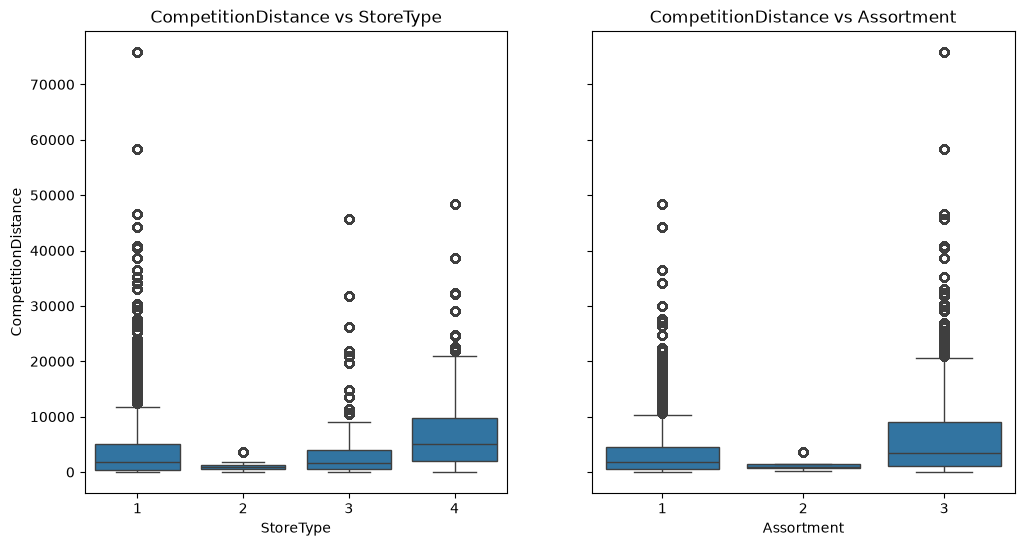

In [31]:
no_competitors = train_df[pd.notna(train_df['CompetitionDistance'])]
fig, ax = plt.subplots(1, 2, sharey=True, figsize=(12, 6))

sns.boxplot(no_competitors, x='StoreType', y='CompetitionDistance', ax=ax[0])
ax[0].set_title("CompetitionDistance vs StoreType")

sns.boxplot(no_competitors, x='Assortment', y='CompetitionDistance', ax=ax[1])
ax[1].set_title("CompetitionDistance vs Assortment")

plt.show()

In [32]:
train_clusters = train_df.copy()
group_medians = train_clusters.groupby(['StoreType', 'Assortment'])[['CompetitionDistance', 'CompetitionMonths']].transform('median')
global_medians = train_clusters[['CompetitionMonths']].median()

In [33]:
train_clusters[['CompetitionDistance', 'CompetitionMonths']] = train_clusters[['CompetitionDistance', 'CompetitionMonths']].fillna(group_medians)
train_clusters[['CompetitionMonths']] = train_clusters[['CompetitionMonths']].fillna(global_medians)

In [34]:
val_clusters = val_df.copy()
val_clusters[['CompetitionDistance', 'CompetitionMonths']] = val_clusters[['CompetitionDistance', 'CompetitionMonths']].fillna(group_medians)
val_clusters[['CompetitionMonths']] = val_clusters[['CompetitionMonths']].fillna(global_medians)

In [35]:
X_train, y_train = train_clusters.drop(columns=['Sales', 'Date']), train_clusters['Sales']
X_val, y_val = val_clusters.drop(columns=['Sales', 'Date']), val_clusters['Sales']

In [36]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [37]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

print("R^2 score =", r2_score(y_val, y_pred))
print("MSE score =", mean_squared_error(y_val, y_pred))
print("RMSE score =", root_mean_squared_error(y_val, y_pred))
print("WAPE score =", wmape(actual, predicted))

R^2 score = 0.9314111480082972
MSE score = 1069643.593041187
RMSE score = 1034.2357531245896
WAPE score = 11.388225715533563


## IterativeImputer / BayesianRidge

In [38]:
bool_features = ['Promo', 'Promo2', 'SchoolHoliday', 'IsPromo2Month']
num_features = train_df.drop(columns=cat_features + bool_features + ['Date', 'Sales']).columns
target_columns = train_df.drop(columns=['Date', 'Sales']).columns

In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[num_features])
X_val_scaled = scaler.transform(val_df[num_features])

In [40]:
br_impute = IterativeImputer(max_iter=3, random_state=42)
X_train_br = pd.DataFrame(scaler.inverse_transform(br_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_br = pd.DataFrame(scaler.inverse_transform(br_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

In [ ]:
X_train_br['CompetitionMonths'] = X_train_br['CompetitionMonths'].astype(int)
X_val_br['CompetitionMonths'] = X_val_br['CompetitionMonths'].astype(int)

In [42]:
X_train = train_df[cat_features + bool_features].join(X_train_br).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_br).reindex(columns=target_columns)
y_val = val_df['Sales']

In [43]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [44]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

print("R^2 score =", r2_score(y_val, y_pred))
print("MSE score =", mean_squared_error(y_val, y_pred))
print("RMSE score =", root_mean_squared_error(y_val, y_pred))
print("WAPE score =", wmape(actual, predicted))

R^2 score = 0.9324240231809086
MSE score = 1053847.798134673
RMSE score = 1026.5708928927768
WAPE score = 11.357630045831625


## IterativeImputer / SVR

In [45]:
%%time

svr_impute = IterativeImputer(estimator=SVR(max_iter=500, cache_size=1000), max_iter=3, random_state=42)
X_train_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

CPU times: total: 29min 27s
Wall time: 44min 58s


In [ ]:
X_train_svr['CompetitionMonths'] = X_train_svr['CompetitionMonths'].astype(int)
X_val_svr['CompetitionMonths'] = X_val_svr['CompetitionMonths'].astype(int)

In [47]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [48]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [49]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

print("R^2 score =", r2_score(y_val, y_pred))
print("MSE score =", mean_squared_error(y_val, y_pred))
print("RMSE score =", root_mean_squared_error(y_val, y_pred))
print("WAPE score =", wmape(actual, predicted))

R^2 score = 0.9322828331756994
MSE score = 1056049.6571844735
RMSE score = 1027.6427673002295
WAPE score = 11.329237894484052


Лучшим оказался ItertativeImputer на SVR

In [50]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

In [51]:
X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [52]:
train_final = X_train.copy()
train_final['Sales'] = y_train
train_final['Date'] = train_df['Date']

In [53]:
val_final = X_val.copy()
val_final['Sales'] = y_val
val_final['Date'] = val_df['Date']

# Обучение

In [54]:
def get_period_config(n_weeks: int) -> dict:
    PERIOD_CONFIG = {
        1:  {'lags': [1, 2, 3, 4], 'windows': [4, 12], 'pct_change': [4, 12]},
        2:  {'lags': [1, 2, 3],    'windows': [2, 6],  'pct_change': [2, 6]},
        4:  {'lags': [1, 2, 3],    'windows': [3, 6],  'pct_change': [1, 3]},
        6:  {'lags': [1, 2],       'windows': [2, 4],  'pct_change': [1, 2]},
        12: {'lags': [1, 2],       'windows': [2, 3],  'pct_change': [1, 2]},
    }

    return PERIOD_CONFIG[n_weeks]

In [55]:
def add_target_features(data: pd.DataFrame, n_weeks: int) -> pd.DataFrame:
    data = data.sort_values(['Store', 'Date'])
    cfg = get_period_config(n_weeks)

    for lag in cfg['lags']:
        data[f'SalesLag{lag}'] = data.groupby('Store')['Sales'].shift(lag)

    for window in cfg['windows']:
        data[f'SalesMean{window}'] = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).mean())
        data[f'SalesStd{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).std())
        data[f'SalesMin{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).min())
        data[f'SalesMax{window}']  = data.groupby('Store')['Sales'].transform(lambda s: s.shift(1).rolling(window).max())

    for periods in cfg['pct_change']:
        weeks_back = periods * n_weeks
        data[f'SalesPctChange{weeks_back}w'] = data.groupby('Store')['Sales'].transform(
            lambda s: s.pct_change(periods).replace(np.inf, np.nan)
        )
        data[f'SalesDiff{weeks_back}w'] = data.groupby('Store')['Sales'].transform(
            lambda s: s.diff(periods)
        )

    return data

In [56]:
def get_target_feature_cols(n_weeks: int) -> list[str]:
    cfg = get_period_config(n_weeks)
    cols = [f'SalesLag{lag}' for lag in cfg['lags']]
    for w in cfg['windows']:
        cols += [f'SalesMean{w}', f'SalesStd{w}', f'SalesMin{w}', f'SalesMax{w}']
    for periods in cfg['pct_change']:
        cols += [f'SalesPctChange{periods * n_weeks}w', f'SalesDiff{periods * n_weeks}w']
    return cols

In [57]:
def aggregate_bucket(full_df: pd.DataFrame, n_weeks: int, agg_dict: dict) -> pd.DataFrame:
    tmp = full_df.copy()
    tmp['WeekNum'] = tmp['Week'].rank(method='dense').astype(int) - 1
    tmp['Bucket'] = tmp['WeekNum'] // n_weeks
    tmp = tmp.drop(columns=['WeekNum'])

    bucket_df = tmp.groupby(['Store', 'Bucket']).agg(agg_dict)
    bucket_df['n_days'] = tmp.groupby(['Store', 'Bucket'])['Date'].count()
    bucket_df = bucket_df[bucket_df['n_days'] == n_weeks * 7]
    bucket_df = bucket_df.drop(columns=['n_days'])

    return bucket_df.reset_index()

In [58]:
def train_model(
    model: LGBMRegressor | CatBoostRegressor,
    data: pd.DataFrame,
    n_steps: int,
    n_weeks: int
):
    is_catboost = isinstance(model, CatBoostRegressor)
    feature_cols = get_target_feature_cols(n_weeks)
    drop_cols = ['Sales', 'Date', 'Bucket']
    true_sales = data.set_index(['Store', 'Bucket'])['Sales']

    train = data[data['Date'] <= cutoff]
    X_train = train.drop(columns=drop_cols).dropna(subset=feature_cols)
    y_train = train.loc[X_train.index, 'Sales']

    if is_catboost:
        X_train[cat_features] = X_train[cat_features].astype(str)
        model.fit(X_train, y_train, cat_features=cat_features)
    else:
        model.fit(X_train, y_train, categorical_feature=cat_features)

    horizon = np.sort(data[data['Date'] > cutoff]['Bucket'].unique())[:n_steps]
    predicted_index = []

    for period in horizon:
        mask = data['Bucket'] == period
        X_step = data.loc[mask].drop(columns=drop_cols).dropna(subset=feature_cols)

        if is_catboost:
            X_step[cat_features] = X_step[cat_features].astype(str)

        y_pred = model.predict(X_step)
        data.loc[X_step.index, 'Sales'] = y_pred
        predicted_index.extend(X_step.index)

        data = add_target_features(data, n_weeks)

    pred_final = data.loc[predicted_index].set_index(['Store', 'Bucket'])['Sales']
    real_final = true_sales.loc[pred_final.index]

    actual = TimeSeries.from_values(real_final)
    predicted = TimeSeries.from_values(pred_final)

    return X_train, wmape(actual, predicted)

In [59]:
def objective(
    trial: optuna.trial.Trial,
    model_type: str,
    data: pd.DataFrame,
    n_steps: int,
    n_weeks: int
):

    if model_type == 'lgbm':
        lr = trial.suggest_float('learning_rate', 1e-3, 1, log=True)
        n_estimators = trial.suggest_int('n_estimators', 500, 2500)
        min_child_samples = trial.suggest_int('min_child_samples', 50, 500)
        num_leaves = trial.suggest_int('num_leaves', 200, 1200)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-3, 10, log=True)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)

        model = LGBMRegressor(
            learning_rate=lr,
            n_estimators=n_estimators,
            min_child_samples=min_child_samples,
            num_leaves=num_leaves,
            reg_lambda=reg_lambda,
            colsample_bytree=colsample_bytree,
            random_state=42, n_jobs=-1, verbosity=-1
        )

    elif model_type == 'cb':
        lr = trial.suggest_float('learning_rate', 1e-3, 1, log=True)
        iterations = trial.suggest_int('iterations', 300, 1200)
        depth = trial.suggest_int('depth', 4, 10)
        bag_temp = trial.suggest_float('bagging_temperature', 0, 10)
        l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 4, 10)
        random_strength = trial.suggest_float('random_strength', 0, 10)
        subsample = trial.suggest_float('subsample', 0.5, 1.0)

        model = CatBoostRegressor(
            learning_rate=lr,
            iterations=iterations,
            depth=depth,
            bagging_temperature=bag_temp,
            l2_leaf_reg=l2_leaf_reg,
            random_strength=random_strength,
            subsample=subsample,
            has_time=True, random_state=42, verbose=False
        )

    _, score = train_model(model, data.copy(), n_steps, n_weeks)

    return score

In [60]:
full_df = pd.concat([train_final, val_final], axis=0).sort_values(['Store', 'Date']).reset_index(drop=True)
full_df['Week'] = full_df['Date'].dt.to_period('W-MON')

In [61]:
first_cols = ['StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear',
              'CompetitionMonths', 'DayOfMonth', 'DayOfWeek', 'DayOfYear', 'Month', 'Year']
max_cols = ['Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'IsPromo2Month']
mean_cols = ['PromoMean7', 'PromoMean28', 'SchoolHolidaySum7', 'SchoolHolidaySum28']

In [62]:
agg_dict = {'Date': 'min', 'Sales': 'sum'}
agg_dict.update({c: 'first' for c in first_cols})
agg_dict.update({c: 'max' for c in max_cols})
agg_dict.update({c: 'mean' for c in mean_cols})

Предсказание по неделе вперед

In [63]:
weeks1_df = aggregate_bucket(full_df, n_weeks=1, agg_dict=agg_dict)

In [64]:
weeks1_df = add_target_features(weeks1_df, n_weeks=1)

In [65]:
weeks1_df = weeks1_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [66]:
study_lgbm_week1 = optuna.create_study(direction="minimize")
study_lgbm_week1.optimize(
    lambda t: objective(t, 'lgbm', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-24 10:08:55,121] A new study created in memory with name: no-name-59c23654-b2ca-4cf3-a6ad-64a0f7bb46c2
[I 2026-07-24 10:09:56,430] Trial 0 finished with value: 0.9071335790724809 and parameters: {'learning_rate': 0.013577874872283967, 'n_estimators': 570, 'min_child_samples': 272, 'num_leaves': 544, 'reg_lambda': 0.10872480257059174, 'colsample_bytree': 0.6817625440846573}. Best is trial 0 with value: 0.9071335790724809.
[I 2026-07-24 10:10:41,927] Trial 1 finished with value: 9.227377347290565 and parameters: {'learning_rate': 0.0020168725834554648, 'n_estimators': 599, 'min_child_samples': 481, 'num_leaves': 1058, 'reg_lambda': 0.17013713336657738, 'colsample_bytree': 0.6898297761433116}. Best is trial 0 with value: 0.9071335790724809.
[I 2026-07-24 10:12:37,380] Trial 2 finished with value: 0.6129920721257635 and parameters: {'learning_rate': 0.026283409868642908, 'n_estimators': 2226, 'min_child_samples': 66, 'num_leaves': 230, 'reg_lambda': 0.011104639645237053, 'colsam

In [67]:
lgbm_model_week1 = LGBMRegressor(**study_lgbm_week1.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week1, score_lgbm_week1 = train_model(
    lgbm_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [68]:
study_cb_week1 = optuna.create_study(direction="minimize")
study_cb_week1.optimize(
    lambda t: objective(t, 'cb', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-24 10:31:34,629] A new study created in memory with name: no-name-e3ab3260-0983-4c2b-8373-34da45995fcb
[I 2026-07-24 10:33:29,348] Trial 0 finished with value: 3.064884048522719 and parameters: {'learning_rate': 0.009197752378923308, 'iterations': 962, 'depth': 5, 'bagging_temperature': 9.753818004466519, 'l2_leaf_reg': 4.159875117019646, 'random_strength': 6.131109710630942, 'subsample': 0.5610569227157347}. Best is trial 0 with value: 3.064884048522719.
[I 2026-07-24 10:35:54,403] Trial 1 finished with value: 8.772596455464674 and parameters: {'learning_rate': 0.001582201439023302, 'iterations': 1096, 'depth': 6, 'bagging_temperature': 3.4953063451528523, 'l2_leaf_reg': 9.206217032182666, 'random_strength': 3.191498421825587, 'subsample': 0.6323638212314627}. Best is trial 0 with value: 3.064884048522719.
[I 2026-07-24 10:38:02,408] Trial 2 finished with value: 1.6412991892352964 and parameters: {'learning_rate': 0.03813823122275648, 'iterations': 789, 'depth': 7, 'bagging

In [69]:
cb_model_week1 = CatBoostRegressor(**study_cb_week1.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week1, score_cb_week1 = train_model(
    cb_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

Предсказание по группировке 2 недели

In [70]:
weeks2_df = aggregate_bucket(full_df, n_weeks=2, agg_dict=agg_dict)

In [71]:
weeks2_df = add_target_features(weeks2_df, n_weeks=2)

In [72]:
weeks2_df = weeks2_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [73]:
study_lgbm_week2 = optuna.create_study(direction="minimize")
study_lgbm_week2.optimize(
    lambda t: objective(t, 'lgbm', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-24 11:00:18,722] A new study created in memory with name: no-name-76e45b8c-ec7f-4903-b255-392dfee31463
[I 2026-07-24 11:00:50,275] Trial 0 finished with value: 1.0966201603465484 and parameters: {'learning_rate': 0.33743691498780004, 'n_estimators': 1252, 'min_child_samples': 338, 'num_leaves': 1101, 'reg_lambda': 0.005359054391949784, 'colsample_bytree': 0.7189130596932664}. Best is trial 0 with value: 1.0966201603465484.
[I 2026-07-24 11:01:39,460] Trial 1 finished with value: 0.7264832035487154 and parameters: {'learning_rate': 0.0016356473142555383, 'n_estimators': 2392, 'min_child_samples': 187, 'num_leaves': 1034, 'reg_lambda': 0.011198520168908006, 'colsample_bytree': 0.9312671863513841}. Best is trial 1 with value: 0.7264832035487154.
[I 2026-07-24 11:02:09,286] Trial 2 finished with value: 0.8532590096049494 and parameters: {'learning_rate': 0.00723467011381215, 'n_estimators': 1377, 'min_child_samples': 449, 'num_leaves': 246, 'reg_lambda': 0.0011240935060328552, '

In [74]:
lgbm_model_week2 = LGBMRegressor(**study_lgbm_week2.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week2, score_lgbm_week2 = train_model(
    lgbm_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [75]:
study_cb_week2 = optuna.create_study(direction="minimize")
study_cb_week2.optimize(
    lambda t: objective(t, 'cb', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-24 11:23:52,541] A new study created in memory with name: no-name-3fadd768-9637-426f-bf6e-af98ca3e8823
[I 2026-07-24 11:25:31,292] Trial 0 finished with value: 0.7987359727376466 and parameters: {'learning_rate': 0.20900790505383193, 'iterations': 1128, 'depth': 5, 'bagging_temperature': 0.7156974304975827, 'l2_leaf_reg': 7.911274733688964, 'random_strength': 5.933492266760353, 'subsample': 0.8770728530854552}. Best is trial 0 with value: 0.7987359727376466.
[I 2026-07-24 11:27:32,641] Trial 1 finished with value: 1.2865795748873128 and parameters: {'learning_rate': 0.05406663759538797, 'iterations': 568, 'depth': 10, 'bagging_temperature': 8.75879054233, 'l2_leaf_reg': 6.18647215918331, 'random_strength': 6.554558000329516, 'subsample': 0.7368559646441065}. Best is trial 0 with value: 0.7987359727376466.
[I 2026-07-24 11:28:37,737] Trial 2 finished with value: 14.179504808238867 and parameters: {'learning_rate': 0.00151827738833879, 'iterations': 708, 'depth': 5, 'bagging_t

In [76]:
cb_model_week2 = CatBoostRegressor(**study_cb_week2.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week2, score_cb_week2 = train_model(
    cb_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

Предсказание по группировке 4 недели


In [77]:
weeks4_df = aggregate_bucket(full_df, n_weeks=4, agg_dict=agg_dict)

In [78]:
weeks4_df = add_target_features(weeks4_df, n_weeks=4)

In [79]:
weeks4_df = weeks4_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [80]:
study_lgbm_week4 = optuna.create_study(direction="minimize")
study_lgbm_week4.optimize(
    lambda t: objective(t, 'lgbm', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-24 11:52:39,319] A new study created in memory with name: no-name-0459d1d1-8138-424d-bfd7-4f1dc45f85f7
[I 2026-07-24 11:52:53,104] Trial 0 finished with value: 0.8634398930149874 and parameters: {'learning_rate': 0.11941772047448819, 'n_estimators': 1004, 'min_child_samples': 473, 'num_leaves': 719, 'reg_lambda': 8.18448833216471, 'colsample_bytree': 0.5279164749331431}. Best is trial 0 with value: 0.8634398930149874.
[I 2026-07-24 11:53:15,305] Trial 1 finished with value: 0.9558788716662644 and parameters: {'learning_rate': 0.2233066526294374, 'n_estimators': 1523, 'min_child_samples': 259, 'num_leaves': 1054, 'reg_lambda': 1.8651231696586623, 'colsample_bytree': 0.5760611763576734}. Best is trial 0 with value: 0.8634398930149874.
[I 2026-07-24 11:53:32,932] Trial 2 finished with value: 0.9595019572719852 and parameters: {'learning_rate': 0.19521609978018375, 'n_estimators': 1143, 'min_child_samples': 382, 'num_leaves': 753, 'reg_lambda': 0.0035096969249989404, 'colsample_

In [81]:
lgbm_model_week4 = LGBMRegressor(**study_lgbm_week4.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week4, score_lgbm_week4 = train_model(
    lgbm_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [82]:
study_cb_week4 = optuna.create_study(direction="minimize")
study_cb_week4.optimize(
    lambda t: objective(t, 'cb', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-24 12:02:24,627] A new study created in memory with name: no-name-e3b2e3e1-38b6-4f9f-8d00-a0f558349bb7
[I 2026-07-24 12:03:14,203] Trial 0 finished with value: 1.0587710256765683 and parameters: {'learning_rate': 0.7709860835260565, 'iterations': 418, 'depth': 8, 'bagging_temperature': 5.840647186730532, 'l2_leaf_reg': 6.378315083872609, 'random_strength': 1.72866175386294, 'subsample': 0.8499563031973314}. Best is trial 0 with value: 1.0587710256765683.
[I 2026-07-24 12:03:45,404] Trial 1 finished with value: 1.1984570927133602 and parameters: {'learning_rate': 0.05774718424337152, 'iterations': 469, 'depth': 4, 'bagging_temperature': 7.595583673227203, 'l2_leaf_reg': 6.9831490994196335, 'random_strength': 0.7647660026273706, 'subsample': 0.7961558947637286}. Best is trial 0 with value: 1.0587710256765683.
[I 2026-07-24 12:04:41,541] Trial 2 finished with value: 8.988142044827727 and parameters: {'learning_rate': 0.0012053486425545926, 'iterations': 1168, 'depth': 4, 'baggi

In [83]:
cb_model_week4 = CatBoostRegressor(**study_cb_week4.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week4, score_cb_week4 = train_model(
    cb_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

Предсказание по группировке 6 недель

In [84]:
weeks6_df = aggregate_bucket(full_df, n_weeks=6, agg_dict=agg_dict)

In [85]:
weeks6_df = add_target_features(weeks6_df, n_weeks=6)

In [86]:
weeks6_df = weeks6_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [87]:
study_lgbm_week6 = optuna.create_study(direction="minimize")
study_lgbm_week6.optimize(
    lambda t: objective(t, 'lgbm', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-24 12:21:35,097] A new study created in memory with name: no-name-4a19ce65-71c6-45ec-9ad0-f700db11bcbe
[I 2026-07-24 12:21:54,745] Trial 0 finished with value: 0.6428334442038831 and parameters: {'learning_rate': 0.04391868990475812, 'n_estimators': 2084, 'min_child_samples': 233, 'num_leaves': 741, 'reg_lambda': 0.3049865187247718, 'colsample_bytree': 0.6515898171451495}. Best is trial 0 with value: 0.6428334442038831.
[I 2026-07-24 12:22:31,154] Trial 1 finished with value: 0.6889183177823769 and parameters: {'learning_rate': 0.20839012002006335, 'n_estimators': 2418, 'min_child_samples': 88, 'num_leaves': 637, 'reg_lambda': 0.044582665330559906, 'colsample_bytree': 0.6029539585371706}. Best is trial 0 with value: 0.6428334442038831.
[I 2026-07-24 12:22:45,850] Trial 2 finished with value: 0.7258174925091495 and parameters: {'learning_rate': 0.039103442199507045, 'n_estimators': 2391, 'min_child_samples': 397, 'num_leaves': 419, 'reg_lambda': 0.08995414619885359, 'colsampl

In [88]:
lgbm_model_week6 = LGBMRegressor(**study_lgbm_week6.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week6, score_lgbm_week6 = train_model(
    lgbm_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [89]:
study_cb_week6 = optuna.create_study(direction="minimize")
study_cb_week6.optimize(
    lambda t: objective(t, 'cb', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-24 12:25:53,614] A new study created in memory with name: no-name-14411d51-9f67-462c-8a9c-4480cdf087fd
[I 2026-07-24 12:26:52,061] Trial 0 finished with value: 5.886263348661633 and parameters: {'learning_rate': 0.0033674536733212194, 'iterations': 567, 'depth': 9, 'bagging_temperature': 9.120215925814263, 'l2_leaf_reg': 5.9630718280085055, 'random_strength': 8.993079547333828, 'subsample': 0.7375216769892596}. Best is trial 0 with value: 5.886263348661633.
[I 2026-07-24 12:29:04,350] Trial 1 finished with value: 1.142401693465782 and parameters: {'learning_rate': 0.00476926579784843, 'iterations': 959, 'depth': 10, 'bagging_temperature': 4.557199191496723, 'l2_leaf_reg': 9.606583884537262, 'random_strength': 0.7500848600612409, 'subsample': 0.7701262734136318}. Best is trial 1 with value: 1.142401693465782.
[I 2026-07-24 12:30:53,341] Trial 2 finished with value: 0.7290245113919451 and parameters: {'learning_rate': 0.0543846529403475, 'iterations': 982, 'depth': 9, 'bagging

In [90]:
cb_model_week6 = CatBoostRegressor(**study_cb_week6.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week6, score_cb_week6 = train_model(
    cb_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

Предсказание по группировке 12 недель

In [91]:
weeks12_df = aggregate_bucket(full_df, n_weeks=12, agg_dict=agg_dict)

In [92]:
weeks12_df = add_target_features(weeks12_df, n_weeks=12)

In [93]:
weeks12_df = weeks12_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [94]:
study_lgbm_week12 = optuna.create_study(direction="minimize")
study_lgbm_week12.optimize(
    lambda t: objective(t, 'lgbm', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-24 12:47:16,150] A new study created in memory with name: no-name-606b94f5-1f0b-4fe0-a154-9cf7e30b4ac0
[I 2026-07-24 12:47:20,370] Trial 0 finished with value: 2.6993801946896188 and parameters: {'learning_rate': 0.11164705684357905, 'n_estimators': 1405, 'min_child_samples': 334, 'num_leaves': 1014, 'reg_lambda': 0.040412277066950886, 'colsample_bytree': 0.7995097319429036}. Best is trial 0 with value: 2.6993801946896188.
[I 2026-07-24 12:47:24,553] Trial 1 finished with value: 3.6075141405126945 and parameters: {'learning_rate': 0.004436853189047918, 'n_estimators': 1320, 'min_child_samples': 390, 'num_leaves': 728, 'reg_lambda': 0.10712840939186631, 'colsample_bytree': 0.7967006354907482}. Best is trial 0 with value: 2.6993801946896188.
[I 2026-07-24 12:47:29,198] Trial 2 finished with value: 1.71892185888373 and parameters: {'learning_rate': 0.009398774565232611, 'n_estimators': 1417, 'min_child_samples': 171, 'num_leaves': 549, 'reg_lambda': 2.9791428631457753, 'colsamp

In [95]:
lgbm_model_week12 = LGBMRegressor(**study_lgbm_week12.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week12, score_lgbm_week12 = train_model(
    lgbm_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [96]:
study_cb_week12 = optuna.create_study(direction="minimize")
study_cb_week12.optimize(
    lambda t: objective(t, 'cb', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-24 12:48:35,918] A new study created in memory with name: no-name-cb93596d-c5ed-445a-8484-6bb3a4eafbb1
[I 2026-07-24 12:50:17,249] Trial 0 finished with value: 1.2140375949468591 and parameters: {'learning_rate': 0.018353050193908767, 'iterations': 1078, 'depth': 9, 'bagging_temperature': 2.335717138271911, 'l2_leaf_reg': 8.931154646639996, 'random_strength': 3.136918798559866, 'subsample': 0.7797476611155183}. Best is trial 0 with value: 1.2140375949468591.
[I 2026-07-24 12:50:46,362] Trial 1 finished with value: 17.985276320326246 and parameters: {'learning_rate': 0.001133561112101569, 'iterations': 360, 'depth': 8, 'bagging_temperature': 6.521771353427351, 'l2_leaf_reg': 8.536809875898792, 'random_strength': 7.575528427809851, 'subsample': 0.6416310624908861}. Best is trial 0 with value: 1.2140375949468591.
[I 2026-07-24 12:51:24,527] Trial 2 finished with value: 1.5039587165776125 and parameters: {'learning_rate': 0.007474994468118068, 'iterations': 1053, 'depth': 4, 'ba

In [97]:
cb_model_week12 = CatBoostRegressor(**study_cb_week12.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week12, score_cb_week12 = train_model(
    cb_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

# Сравнение качества

In [98]:
pd.DataFrame(
    [score_lgbm_week1, score_cb_week1, score_lgbm_week2, score_cb_week2,
    score_lgbm_week4, score_cb_week4, score_lgbm_week6, score_cb_week6,
    score_lgbm_week12, score_cb_week12],

    index=['LGBM week1', 'CatBoost week1', 'LGBM week2', 'CatBoost week2',
    'LGBM week4', 'CatBoost week4', 'LGBM week6', 'CatBoost week6',
    'LGBM week12', 'CatBoost week12'],

    columns=['WAPE score']
).sort_values(by='WAPE score')

,WAPE score
LGBM week2,0.411485
LGBM week6,0.467157
LGBM week4,0.488075
CatBoost week6,0.559141
CatBoost week4,0.600706
LGBM week1,0.612992
CatBoost week2,0.613737
CatBoost week1,0.656312
CatBoost week12,0.768604
LGBM week12,0.924373


# Feature Importance

CatBoost

In [178]:
pd.DataFrame({
    'feature_name': cb_model_week6.feature_names_,
    'importance': cb_model_week6.feature_importances_ / np.sum(cb_model_week6.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

,feature_name,importance
0,SalesLag1,0.218854
1,SalesMean2,0.131725
2,SalesLag2,0.098908
3,SalesMax2,0.095728
4,SalesMean4,0.090930


In [179]:
explainer_cb = shap.TreeExplainer(cb_model_week6)
shap_values_cb = explainer_cb(cb_train_week6)

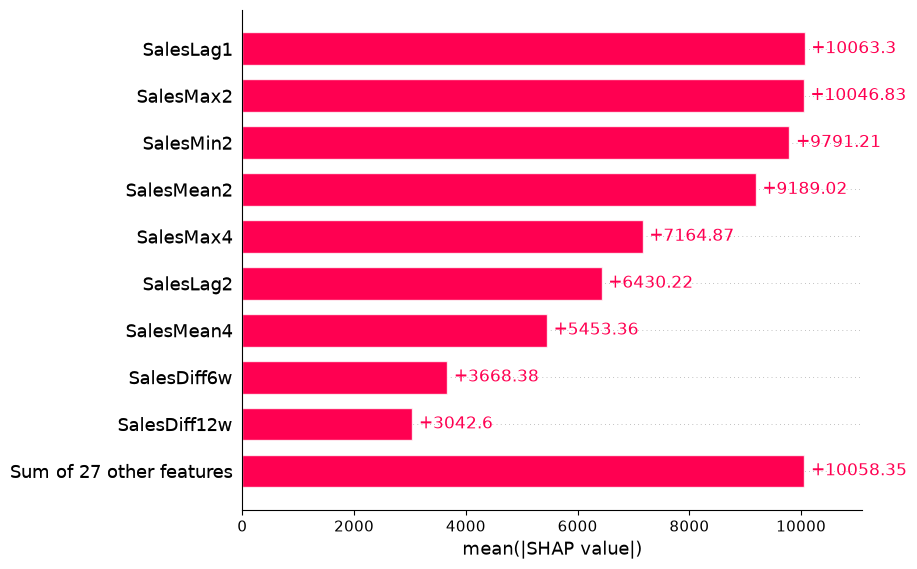

In [180]:
shap.plots.bar(shap_values_cb)

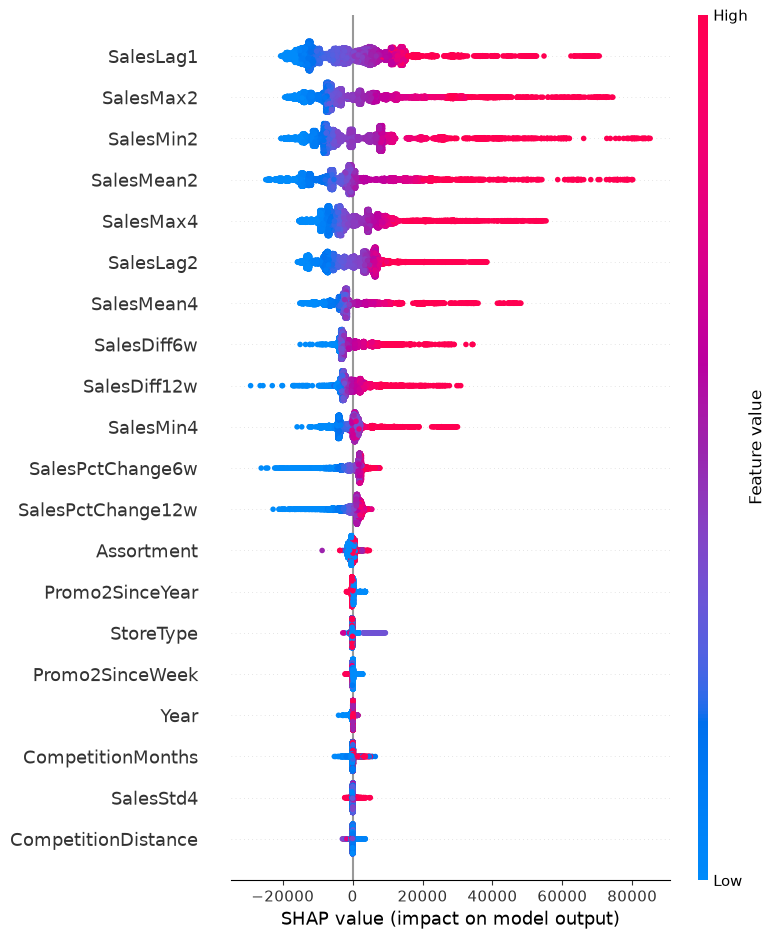

In [181]:
shap.summary_plot(shap_values_cb)

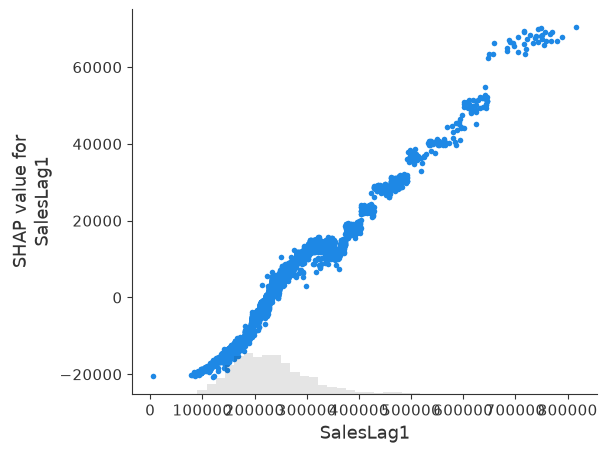

In [182]:
shap.plots.scatter(shap_values_cb[:, "SalesLag1"])

LightGBM

In [183]:
pd.DataFrame({
    'feature_name': lgbm_model_week2.feature_name_,
    'importance': lgbm_model_week2.feature_importances_ / np.sum(lgbm_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

,feature_name,importance
0,Store,0.098950
1,SalesLag2,0.074729
2,SalesPctChange4w,0.065703
3,SalesDiff4w,0.064809
4,SalesStd6,0.058414


In [ ]:
# explainer_lgbm = shap.TreeExplainer(lgbm_model_week2)
# shap_values_lgbm = explainer_lgbm(lgbm_train_week2)

In [106]:
# shap.plots.bar(shap_values_lgbm)

In [107]:
# shap.summary_plot(shap_values_lgbm)

In [108]:
# shap.plots.scatter(shap_values_lgbm[:, "Store"])

# Сплит ВР

Делим данные на трейн и валидационные. Первые 85% в трейн, оставшиеся 15% в валидацию

In [109]:
df['Date'].quantile(0.85)

Timestamp('2015-03-17 00:00:00')

In [110]:
cutoff = df['Date'].quantile(0.85)
train_df = df[df['Date'] <= cutoff]
val_df = df[df['Date'] > cutoff]

# Удаление выбросов

In [111]:
open_df = train_df[train_df['Open'] == 1]
q1 = open_df.groupby('Store')['Sales'].quantile(0.25)
q3 = open_df.groupby('Store')['Sales'].quantile(0.75)
iqr = q3 - q1

In [112]:
lower_bound = train_df['Store'].map(q1 - 1.5 * iqr)
upper_bound = train_df['Store'].map(q3 + 1.5 * iqr)
is_outlier = (train_df['Open'] == 1) & ((train_df['Sales'] < lower_bound) | (train_df['Sales'] > upper_bound))
print(f"В датасете всего {train_df[is_outlier].shape[0]} выбросов. Или в процентах: {train_df[is_outlier].shape[0]/train_df.shape[0]:.2%}")

В датасете всего 15285 выбросов. Или в процентах: 1.77%


In [113]:
train_df = train_df[~is_outlier]

# Пропуски в данных

In [114]:
missing = train_df.isna().sum()
missing_columns = missing[missing > 0].index.tolist()
missing[missing > 0]

CompetitionDistance      2189
CompetitionMonths      270396
PromoMean7               7697
PromoMean28             31059
SchoolHolidaySum7        7697
SchoolHolidaySum28      31059
dtype: int64

In [115]:
bool_features = ['Promo', 'Promo2', 'SchoolHoliday', 'IsPromo2Month']
num_features = train_df.drop(columns=cat_features + bool_features + ['Date', 'Sales']).columns
target_columns = train_df.drop(columns=['Date', 'Sales']).columns

In [116]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_df[num_features])
X_val_scaled = scaler.transform(val_df[num_features])

## IterativeImputer / SVR

In [117]:
%%time

svr_impute = IterativeImputer(estimator=SVR(max_iter=500, cache_size=1000), max_iter=3, random_state=42)
X_train_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.fit_transform(X_train_scaled)), columns=num_features, index=train_df.index)
X_val_svr = pd.DataFrame(scaler.inverse_transform(svr_impute.transform(X_val_scaled)), columns=num_features, index=val_df.index)

CPU times: total: 26min 50s
Wall time: 27min 58s


In [118]:
X_train_svr['CompetitionMonths'] = X_train_svr['CompetitionMonths'].astype(int)
X_val_svr['CompetitionMonths'] = X_val_svr['CompetitionMonths'].astype(int)

In [119]:
X_train = train_df[cat_features + bool_features].join(X_train_svr).reindex(columns=target_columns)
y_train = train_df['Sales']

X_val = val_df[cat_features + bool_features].join(X_val_svr).reindex(columns=target_columns)
y_val = val_df['Sales']

In [120]:
lgbm_model = LGBMRegressor(random_state=42, n_jobs=-1, verbosity=-1)
lgbm_model.fit(X_train, y_train, categorical_feature=cat_features)

,random_state,42
,n_jobs,-1
,verbosity,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None


In [121]:
y_pred = lgbm_model.predict(X_val)
actual = TimeSeries.from_values(y_val)
predicted = TimeSeries.from_values(y_pred)

print("R^2 score =", r2_score(y_val, y_pred))
print("MSE score =", mean_squared_error(y_val, y_pred))
print("RMSE score =", root_mean_squared_error(y_val, y_pred))
print("WAPE score =", wmape(actual, predicted))

R^2 score = 0.9276596473782929
MSE score = 1128148.2697729033
RMSE score = 1062.1432435283402
WAPE score = 11.186190574934939


Подготовка данных

In [122]:
train_final = X_train.copy()
train_final['Sales'] = y_train
train_final['Date'] = train_df['Date']

In [123]:
val_final = X_val.copy()
val_final['Sales'] = y_val
val_final['Date'] = val_df['Date']

# Обучение

In [124]:
full_df = pd.concat([train_final, val_final], axis=0).sort_values(['Store', 'Date']).reset_index(drop=True)
full_df['Week'] = full_df['Date'].dt.to_period('W-MON')

Предсказание по неделе вперед

In [125]:
weeks1_df = aggregate_bucket(full_df, n_weeks=1, agg_dict=agg_dict)

In [126]:
weeks1_df = add_target_features(weeks1_df, n_weeks=1)

In [127]:
weeks1_df = weeks1_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [128]:
study_lgbm_week1 = optuna.create_study(direction="minimize")
study_lgbm_week1.optimize(
    lambda t: objective(t, 'lgbm', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-24 13:28:39,096] A new study created in memory with name: no-name-b7600d7a-6d22-4c5a-96d5-e1dd56731e7c
[I 2026-07-24 13:30:54,630] Trial 0 finished with value: 0.9451131072106389 and parameters: {'learning_rate': 0.09895083207930666, 'n_estimators': 1622, 'min_child_samples': 85, 'num_leaves': 989, 'reg_lambda': 4.090939181497922, 'colsample_bytree': 0.7844140052756232}. Best is trial 0 with value: 0.9451131072106389.
[I 2026-07-24 13:32:32,215] Trial 1 finished with value: 1.031607396846192 and parameters: {'learning_rate': 0.010237328108729083, 'n_estimators': 2435, 'min_child_samples': 418, 'num_leaves': 957, 'reg_lambda': 0.0010570542005148913, 'colsample_bytree': 0.5117703071384628}. Best is trial 0 with value: 0.9451131072106389.
[I 2026-07-24 13:34:19,391] Trial 2 finished with value: 0.8448245021432607 and parameters: {'learning_rate': 0.008854631336150571, 'n_estimators': 2081, 'min_child_samples': 237, 'num_leaves': 340, 'reg_lambda': 5.327650105404025, 'colsample_

In [129]:
lgbm_model_week1 = LGBMRegressor(**study_lgbm_week1.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week1, score_lgbm_week1 = train_model(
    lgbm_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

In [130]:
study_cb_week1 = optuna.create_study(direction="minimize")
study_cb_week1.optimize(
    lambda t: objective(t, 'cb', weeks1_df.copy(), n_steps=12, n_weeks=1),
    n_trials=15
)

[I 2026-07-24 13:57:50,395] A new study created in memory with name: no-name-5666c556-607b-49ae-af2d-1a520dd5db7f
[I 2026-07-24 14:00:04,462] Trial 0 finished with value: 10.300046741200985 and parameters: {'learning_rate': 0.0038841324525586305, 'iterations': 402, 'depth': 8, 'bagging_temperature': 8.841862460805213, 'l2_leaf_reg': 9.319317635860394, 'random_strength': 9.850408563801539, 'subsample': 0.5331990283894592}. Best is trial 0 with value: 10.300046741200985.
[I 2026-07-24 14:02:48,215] Trial 1 finished with value: 0.7229201602164367 and parameters: {'learning_rate': 0.16874008171759078, 'iterations': 606, 'depth': 9, 'bagging_temperature': 6.0273116930171335, 'l2_leaf_reg': 5.577250099955015, 'random_strength': 2.0543283779693255, 'subsample': 0.5550710737923564}. Best is trial 1 with value: 0.7229201602164367.
[I 2026-07-24 14:07:07,867] Trial 2 finished with value: 0.6549780810897252 and parameters: {'learning_rate': 0.5207325478865916, 'iterations': 770, 'depth': 10, 'bag

In [131]:
cb_model_week1 = CatBoostRegressor(**study_cb_week1.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week1, score_cb_week1 = train_model(
    cb_model_week1, weeks1_df.copy(), n_steps=12, n_weeks=1
)

Предсказание по группировке 2 недели

In [132]:
weeks2_df = aggregate_bucket(full_df, n_weeks=2, agg_dict=agg_dict)

In [133]:
weeks2_df = add_target_features(weeks2_df, n_weeks=2)

In [134]:
weeks2_df = weeks2_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [135]:
study_lgbm_week2 = optuna.create_study(direction="minimize")
study_lgbm_week2.optimize(
    lambda t: objective(t, 'lgbm', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-24 14:49:00,299] A new study created in memory with name: no-name-56f97159-ad23-44c7-8409-30056b6da2f6
[I 2026-07-24 14:49:45,271] Trial 0 finished with value: 0.589611500695758 and parameters: {'learning_rate': 0.008885640547593944, 'n_estimators': 1173, 'min_child_samples': 90, 'num_leaves': 387, 'reg_lambda': 0.01070290939554456, 'colsample_bytree': 0.7784460672854487}. Best is trial 0 with value: 0.589611500695758.
[I 2026-07-24 14:50:25,707] Trial 1 finished with value: 1.2974764519336415 and parameters: {'learning_rate': 0.0022339015894831567, 'n_estimators': 2284, 'min_child_samples': 474, 'num_leaves': 986, 'reg_lambda': 0.5783274851351947, 'colsample_bytree': 0.5929601523595311}. Best is trial 0 with value: 0.589611500695758.
[I 2026-07-24 14:51:14,877] Trial 2 finished with value: 0.8689506749221904 and parameters: {'learning_rate': 0.002524671905556268, 'n_estimators': 1729, 'min_child_samples': 106, 'num_leaves': 425, 'reg_lambda': 5.895253247649938, 'colsample_b

In [136]:
lgbm_model_week2 = LGBMRegressor(**study_lgbm_week2.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week2, score_lgbm_week2 = train_model(
    lgbm_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

In [137]:
study_cb_week2 = optuna.create_study(direction="minimize")
study_cb_week2.optimize(
    lambda t: objective(t, 'cb', weeks2_df.copy(), n_steps=6, n_weeks=2),
    n_trials=15
)

[I 2026-07-24 15:00:31,080] A new study created in memory with name: no-name-778867be-1cd1-4109-8ca4-4632251be805
[I 2026-07-24 15:02:26,285] Trial 0 finished with value: 18.60652120680061 and parameters: {'learning_rate': 0.0017901528952170252, 'iterations': 335, 'depth': 9, 'bagging_temperature': 0.7929825086987596, 'l2_leaf_reg': 4.437450333477179, 'random_strength': 2.6860691290297, 'subsample': 0.6677959612409479}. Best is trial 0 with value: 18.60652120680061.
[I 2026-07-24 15:04:26,844] Trial 1 finished with value: 0.9718166446771249 and parameters: {'learning_rate': 0.16575356435439167, 'iterations': 350, 'depth': 7, 'bagging_temperature': 6.091211796876478, 'l2_leaf_reg': 6.31065324868816, 'random_strength': 1.5909354013964339, 'subsample': 0.7836883417134802}. Best is trial 1 with value: 0.9718166446771249.
[I 2026-07-24 15:06:22,460] Trial 2 finished with value: 1.3905594620991097 and parameters: {'learning_rate': 0.03057625005824318, 'iterations': 591, 'depth': 4, 'bagging_

In [138]:
cb_model_week2 = CatBoostRegressor(**study_cb_week2.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week2, score_cb_week2 = train_model(
    cb_model_week2, weeks2_df.copy(), n_steps=6, n_weeks=2
)

Предсказание по группировке 4 недели


In [139]:
weeks4_df = aggregate_bucket(full_df, n_weeks=4, agg_dict=agg_dict)

In [140]:
weeks4_df = add_target_features(weeks4_df, n_weeks=4)

In [141]:
weeks4_df = weeks4_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [142]:
study_lgbm_week4 = optuna.create_study(direction="minimize")
study_lgbm_week4.optimize(
    lambda t: objective(t, 'lgbm', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-24 15:41:27,689] A new study created in memory with name: no-name-d6d2e16e-e67f-4ab0-b8e1-e03d19257e5f
[I 2026-07-24 15:41:42,796] Trial 0 finished with value: 3.628507462621708 and parameters: {'learning_rate': 0.0010957022710663916, 'n_estimators': 2050, 'min_child_samples': 426, 'num_leaves': 613, 'reg_lambda': 0.029611499311326447, 'colsample_bytree': 0.9018276772440519}. Best is trial 0 with value: 3.628507462621708.
[I 2026-07-24 15:41:54,548] Trial 1 finished with value: 1.490013655915083 and parameters: {'learning_rate': 0.009905585829850445, 'n_estimators': 627, 'min_child_samples': 352, 'num_leaves': 1129, 'reg_lambda': 0.9442460366970363, 'colsample_bytree': 0.7127007785144674}. Best is trial 1 with value: 1.490013655915083.
[I 2026-07-24 15:42:08,969] Trial 2 finished with value: 1.8999464360143234 and parameters: {'learning_rate': 0.8293619759227078, 'n_estimators': 1146, 'min_child_samples': 285, 'num_leaves': 626, 'reg_lambda': 0.03208745697929238, 'colsample_

In [143]:
lgbm_model_week4 = LGBMRegressor(**study_lgbm_week4.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week4, score_lgbm_week4 = train_model(
    lgbm_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

In [144]:
study_cb_week4 = optuna.create_study(direction="minimize")
study_cb_week4.optimize(
    lambda t: objective(t, 'cb', weeks4_df.copy(), n_steps=3, n_weeks=4),
    n_trials=15
)

[I 2026-07-24 15:46:48,101] A new study created in memory with name: no-name-9b83f82d-5133-4d88-a419-180700f63f42
[I 2026-07-24 15:49:03,918] Trial 0 finished with value: 1.6567201983495545 and parameters: {'learning_rate': 0.0126754311597511, 'iterations': 900, 'depth': 9, 'bagging_temperature': 1.003495653093801, 'l2_leaf_reg': 7.437562760948895, 'random_strength': 6.300372300442517, 'subsample': 0.9896719148390736}. Best is trial 0 with value: 1.6567201983495545.
[I 2026-07-24 15:50:06,077] Trial 1 finished with value: 1.2991220194732849 and parameters: {'learning_rate': 0.025267349286111643, 'iterations': 395, 'depth': 9, 'bagging_temperature': 4.059116461063089, 'l2_leaf_reg': 5.146057506500985, 'random_strength': 0.6113854887946257, 'subsample': 0.9672977634905009}. Best is trial 1 with value: 1.2991220194732849.
[I 2026-07-24 15:51:01,158] Trial 2 finished with value: 1.635256353173044 and parameters: {'learning_rate': 0.019800911153589028, 'iterations': 844, 'depth': 4, 'baggin

In [145]:
cb_model_week4 = CatBoostRegressor(**study_cb_week4.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week4, score_cb_week4 = train_model(
    cb_model_week4, weeks4_df.copy(), n_steps=3, n_weeks=4
)

Предсказание по группировке 6 недель

In [146]:
weeks6_df = aggregate_bucket(full_df, n_weeks=6, agg_dict=agg_dict)

In [147]:
weeks6_df = add_target_features(weeks6_df, n_weeks=6)

In [148]:
weeks6_df = weeks6_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [149]:
study_lgbm_week6 = optuna.create_study(direction="minimize")
study_lgbm_week6.optimize(
    lambda t: objective(t, 'lgbm', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-24 16:08:55,218] A new study created in memory with name: no-name-bb9f926c-ee25-49aa-815f-322c0323ffe3
[I 2026-07-24 16:09:14,659] Trial 0 finished with value: 0.7518435422272653 and parameters: {'learning_rate': 0.09612483658761355, 'n_estimators': 2351, 'min_child_samples': 74, 'num_leaves': 283, 'reg_lambda': 0.031133451229725172, 'colsample_bytree': 0.9703714373747674}. Best is trial 0 with value: 0.7518435422272653.
[I 2026-07-24 16:09:21,746] Trial 1 finished with value: 2.509585565285842 and parameters: {'learning_rate': 0.5884594514570305, 'n_estimators': 630, 'min_child_samples': 391, 'num_leaves': 463, 'reg_lambda': 2.145574212813932, 'colsample_bytree': 0.9318762691375291}. Best is trial 0 with value: 0.7518435422272653.
[I 2026-07-24 16:09:30,545] Trial 2 finished with value: 2.0487522738219273 and parameters: {'learning_rate': 0.08072236152536455, 'n_estimators': 2201, 'min_child_samples': 390, 'num_leaves': 295, 'reg_lambda': 0.339977302452431, 'colsample_bytre

In [150]:
lgbm_model_week6 = LGBMRegressor(**study_lgbm_week6.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week6, score_lgbm_week6 = train_model(
    lgbm_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

In [151]:
study_cb_week6 = optuna.create_study(direction="minimize")
study_cb_week6.optimize(
    lambda t: objective(t, 'cb', weeks6_df.copy(), n_steps=2, n_weeks=6),
    n_trials=15
)

[I 2026-07-24 16:11:54,684] A new study created in memory with name: no-name-b365634e-3413-4dec-95de-f93edbb6b96d
[I 2026-07-24 16:12:44,570] Trial 0 finished with value: 3.8674839195672153 and parameters: {'learning_rate': 0.0056584040191950446, 'iterations': 493, 'depth': 7, 'bagging_temperature': 7.610950871870813, 'l2_leaf_reg': 8.261864386774452, 'random_strength': 6.762850774710165, 'subsample': 0.8778529957022794}. Best is trial 0 with value: 3.8674839195672153.
[I 2026-07-24 16:14:02,482] Trial 1 finished with value: 2.2960972343986046 and parameters: {'learning_rate': 0.0036041567817919544, 'iterations': 1001, 'depth': 6, 'bagging_temperature': 7.8784034972958485, 'l2_leaf_reg': 4.232455592611626, 'random_strength': 4.268645061491787, 'subsample': 0.624071838696463}. Best is trial 1 with value: 2.2960972343986046.
[I 2026-07-24 16:14:55,003] Trial 2 finished with value: 4.879651052938712 and parameters: {'learning_rate': 0.003550963362482436, 'iterations': 639, 'depth': 6, 'ba

In [152]:
cb_model_week6 = CatBoostRegressor(**study_cb_week6.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week6, score_cb_week6 = train_model(
    cb_model_week6, weeks6_df.copy(), n_steps=2, n_weeks=6
)

Предсказание по группировке 12 недель

In [153]:
weeks12_df = aggregate_bucket(full_df, n_weeks=12, agg_dict=agg_dict)

In [154]:
weeks12_df = add_target_features(weeks12_df, n_weeks=12)

In [155]:
weeks12_df = weeks12_df.astype({
    'Store': 'category',
    'StoreType': 'category',
    'Assortment': 'category',
    'StateHoliday': 'category',
    'DayOfWeek': 'category',
    'Promo': 'bool',
    'Promo2': 'bool',
    'SchoolHoliday': 'bool',
    'IsPromo2Month': 'bool',
    'Promo2SinceWeek': 'int',
    'Promo2SinceYear': 'int',
    'Sales': 'float'
})

In [156]:
study_lgbm_week12 = optuna.create_study(direction="minimize")
study_lgbm_week12.optimize(
    lambda t: objective(t, 'lgbm', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-24 16:38:02,887] A new study created in memory with name: no-name-a79764ae-9e84-4eec-85a3-b2799946088e
[I 2026-07-24 16:38:06,974] Trial 0 finished with value: 6.30495165012455 and parameters: {'learning_rate': 0.03777872492908632, 'n_estimators': 1189, 'min_child_samples': 240, 'num_leaves': 996, 'reg_lambda': 0.3319595186978693, 'colsample_bytree': 0.5356379092039815}. Best is trial 0 with value: 6.30495165012455.
[I 2026-07-24 16:38:11,000] Trial 1 finished with value: 7.552976158392562 and parameters: {'learning_rate': 0.0016601071736691213, 'n_estimators': 1146, 'min_child_samples': 252, 'num_leaves': 1179, 'reg_lambda': 0.13937594224782351, 'colsample_bytree': 0.7646085632645339}. Best is trial 0 with value: 6.30495165012455.
[I 2026-07-24 16:38:15,293] Trial 2 finished with value: 6.973637449274354 and parameters: {'learning_rate': 0.30134145199197176, 'n_estimators': 2496, 'min_child_samples': 218, 'num_leaves': 214, 'reg_lambda': 1.0179727002849408, 'colsample_bytre

In [157]:
lgbm_model_week12 = LGBMRegressor(**study_lgbm_week12.best_params, random_state=42, n_jobs=-1, verbosity=-1)
lgbm_train_week12, score_lgbm_week12 = train_model(
    lgbm_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

In [158]:
study_cb_week12 = optuna.create_study(direction="minimize")
study_cb_week12.optimize(
    lambda t: objective(t, 'cb', weeks12_df.copy(), n_steps=1, n_weeks=12),
    n_trials=15
)

[I 2026-07-24 16:39:31,177] A new study created in memory with name: no-name-f42f54da-1284-4723-b9b0-0aa7c0d6115f
[I 2026-07-24 16:40:46,904] Trial 0 finished with value: 1.4321380147157694 and parameters: {'learning_rate': 0.17247490495251866, 'iterations': 1113, 'depth': 7, 'bagging_temperature': 9.523067397783919, 'l2_leaf_reg': 9.803974114488263, 'random_strength': 2.194911901747354, 'subsample': 0.6257641188266234}. Best is trial 0 with value: 1.4321380147157694.
[I 2026-07-24 16:43:06,353] Trial 1 finished with value: 1.282245640499357 and parameters: {'learning_rate': 0.020016815926628677, 'iterations': 1161, 'depth': 8, 'bagging_temperature': 3.23823944955559, 'l2_leaf_reg': 4.3799026634791876, 'random_strength': 7.808385951532154, 'subsample': 0.9865574995706332}. Best is trial 1 with value: 1.282245640499357.
[I 2026-07-24 16:43:42,844] Trial 2 finished with value: 1.5063749162637936 and parameters: {'learning_rate': 0.18159229406152635, 'iterations': 414, 'depth': 8, 'baggin

In [159]:
cb_model_week12 = CatBoostRegressor(**study_cb_week12.best_params, has_time=True, random_state=42, verbose=False)
cb_train_week12, score_cb_week12 = train_model(
    cb_model_week12, weeks12_df.copy(), n_steps=1, n_weeks=12
)

# Сравнение качества

In [160]:
pd.DataFrame(
    [score_lgbm_week1, score_cb_week1, score_lgbm_week2, score_cb_week2,
    score_lgbm_week4, score_cb_week4, score_lgbm_week6, score_cb_week6,
    score_lgbm_week12, score_cb_week12],

    index=['LGBM week1', 'CatBoost week1', 'LGBM week2', 'CatBoost week2',
    'LGBM week4', 'CatBoost week4', 'LGBM week6', 'CatBoost week6',
    'LGBM week12', 'CatBoost week12'],

    columns=['WAPE score']
).sort_values(by='WAPE score')

,WAPE score
CatBoost week1,0.547542
CatBoost week4,0.576679
LGBM week2,0.585220
CatBoost week2,0.656926
CatBoost week6,0.670993
LGBM week1,0.714639
LGBM week6,0.748468
LGBM week4,0.774375
CatBoost week12,1.129500
LGBM week12,2.133620


# Feature Importance

CatBoost

In [171]:
pd.DataFrame({
    'feature_name': cb_model_week1.feature_names_,
    'importance': cb_model_week1.feature_importances_ / np.sum(cb_model_week1.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

,feature_name,importance
0,SalesMean12,0.340239
1,SalesMin12,0.244899
2,SalesMin4,0.170075
3,SalesDiff4w,0.070744
4,SalesLag4,0.069518


In [172]:
explainer_cb = shap.TreeExplainer(cb_model_week1)
shap_values_cb = explainer_cb(cb_train_week1)

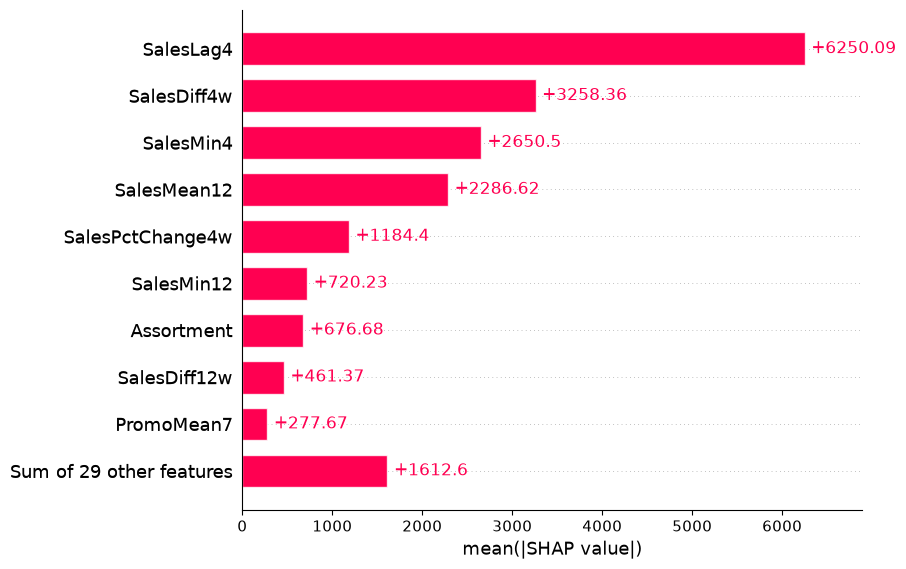

In [173]:
shap.plots.bar(shap_values_cb)

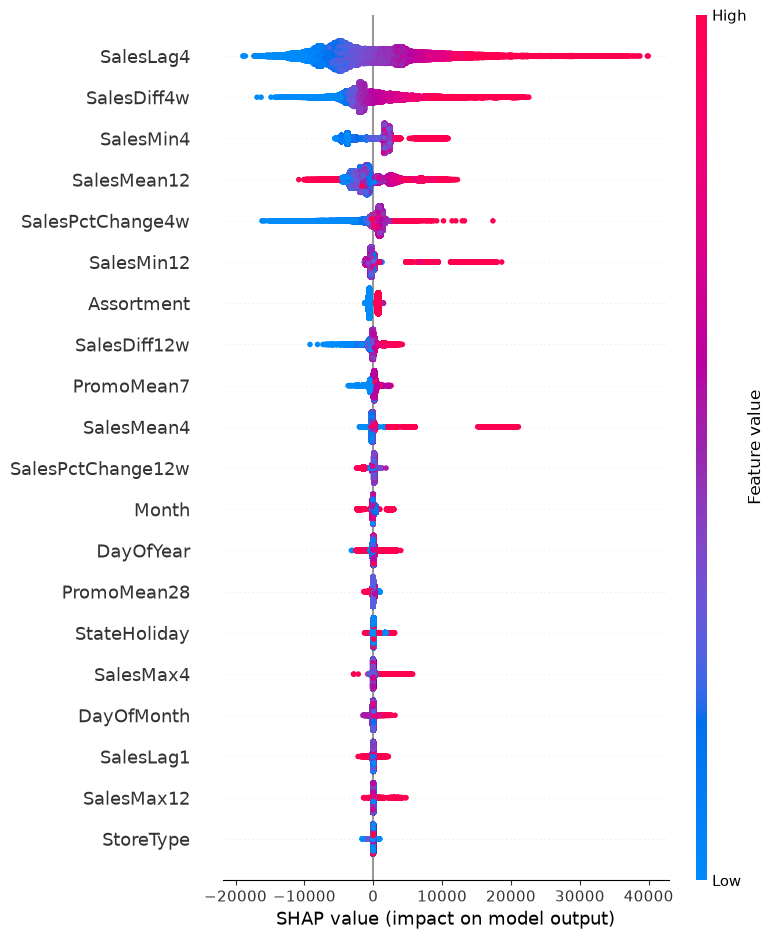

In [174]:
shap.summary_plot(shap_values_cb)

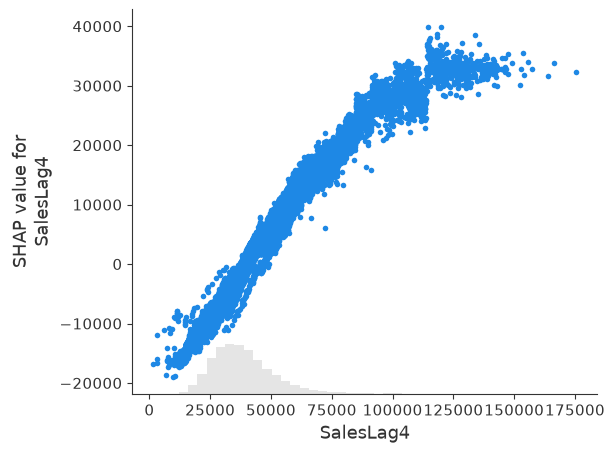

In [176]:
shap.plots.scatter(shap_values_cb[:, "SalesLag4"])

LightGBM

In [177]:
pd.DataFrame({
    'feature_name': lgbm_model_week2.feature_name_,
    'importance': lgbm_model_week2.feature_importances_ / np.sum(lgbm_model_week2.feature_importances_)
}).sort_values(by='importance', ascending=False)[:5].reset_index(drop=True)

,feature_name,importance
0,Store,0.098950
1,SalesLag2,0.074729
2,SalesPctChange4w,0.065703
3,SalesDiff4w,0.064809
4,SalesStd6,0.058414


In [ ]:
# explainer_lgbm = shap.TreeExplainer(lgbm_model_week2)
# shap_values_lgbm = explainer_lgbm(lgbm_train_week2)

In [168]:
# shap.plots.bar(shap_values_lgbm)

In [169]:
# shap.summary_plot(shap_values_lgbm)

In [ ]:
# shap.plots.scatter(shap_values_lgbm[:, "Store"])